# NLP Primer

## What is Language

Language is a structured system of communication that involves complex combinations of its constituent components, such as characters, words, sentences, etc. Linguistics is the systematic study of language. In order to study NLP, it is important to understand some concepts from linguistics about how language is structured. In this section, we’ll introduce them and cover how they relate to some of the NLP tasks we listed earlier.

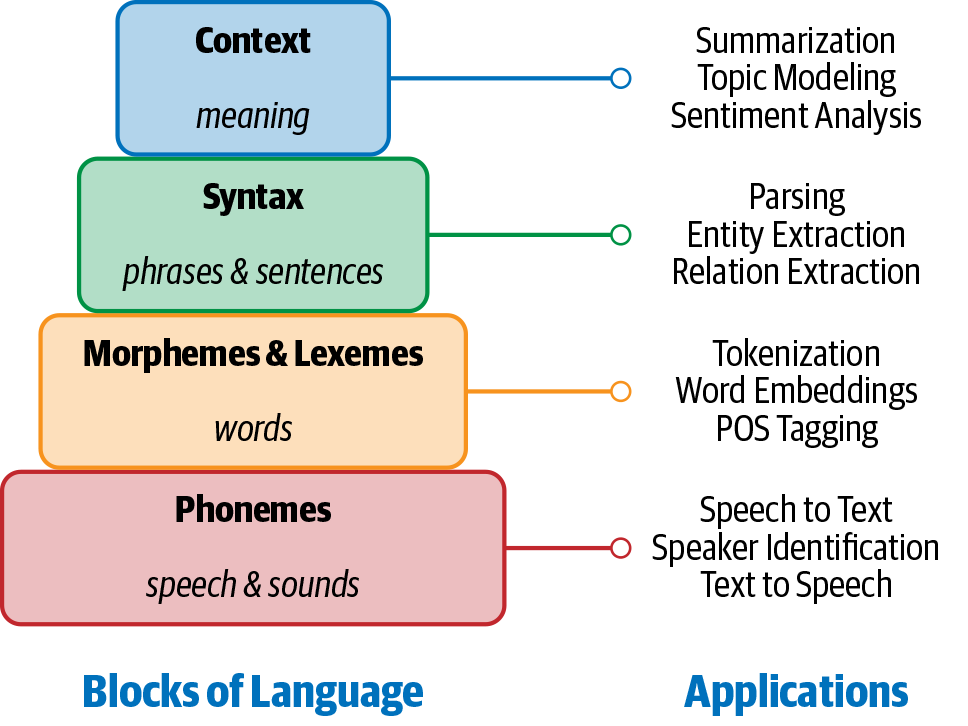

### Building Blocks Of Language

Let’s first introduce what these blocks of language are to give context for the challenges involved in NLP.

#### Phonemes

Phonemes are the smallest units of sound in a language.

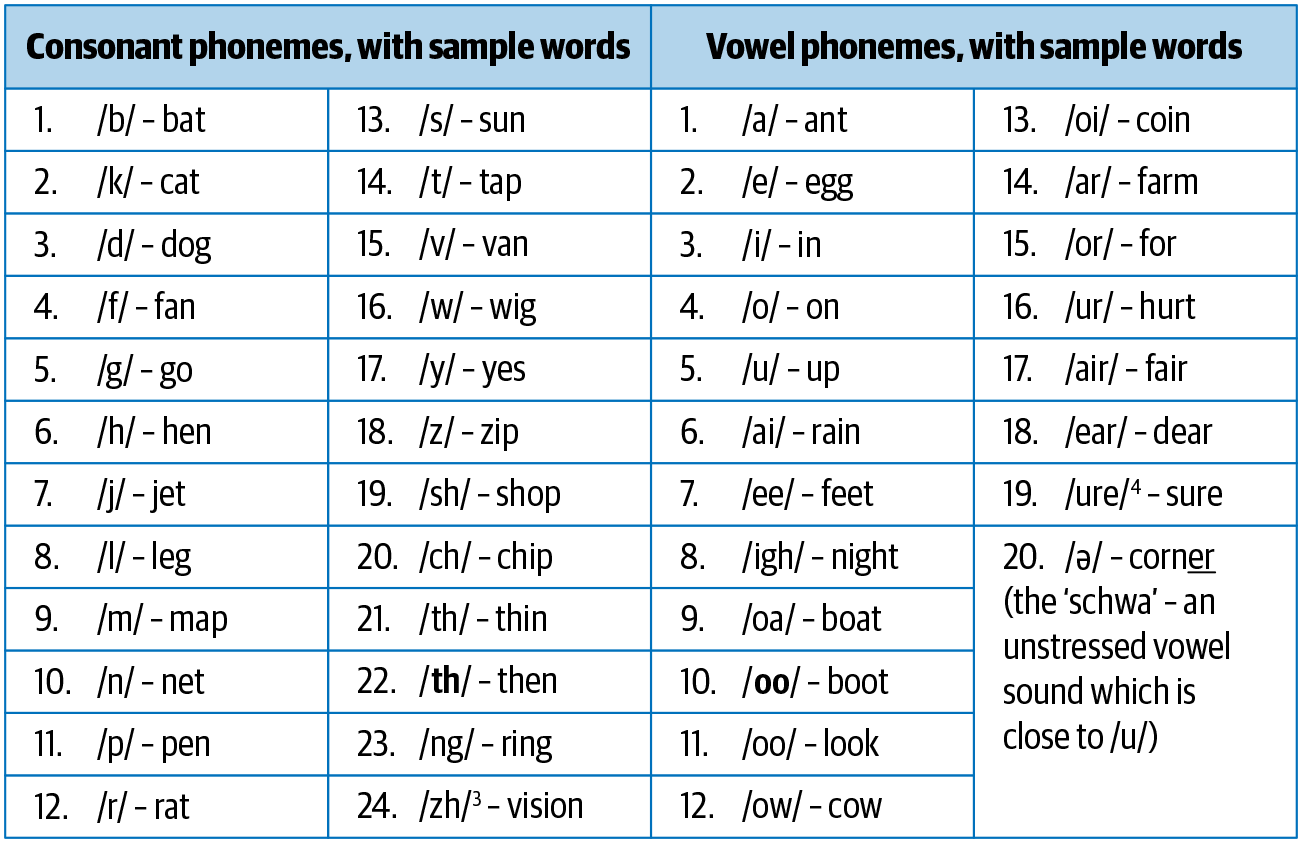


#### Morphemes and lexemes

A morpheme is the smallest unit of language that has a meaning. It is formed by a combination of phonemes. Not all morphemes are words, but all prefixes and suffixes are morphemes. For example, in the word “multimedia,” “multi-” is not a word but a prefix that changes the meaning when put together with “media.” “Multi-” is a morpheme.

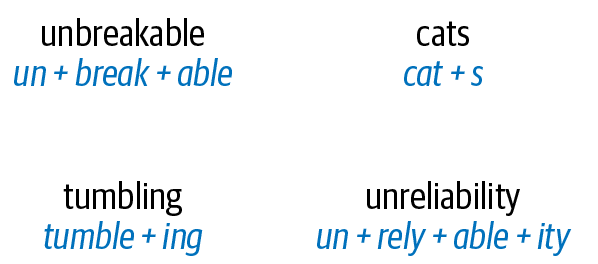


#### Syntax

Syntax is a set of rules to construct grammatically correct sentences out of words and phrases in a language. Syntactic structure in linguistics is represented in many different ways. A common approach to representing sentences is a parse tree. Figure 1-6 shows an example parse tree for two English sentences.

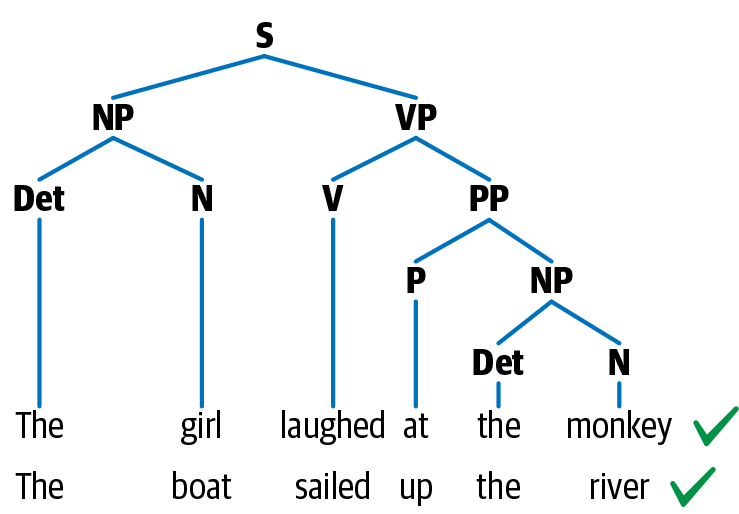

In Figure 1-6, both sentences have a similar structure and hence a similar syntactic parse tree. In this representation, N stands for noun, V for verb, and P for preposition. Noun phrase is denoted by NP and verb phrase by VP. The two noun phrases are “The girl” and “The boat,” while the two verb phrases are “laughed at the monkey” and “sailed up the river.” The syntactic structure is guided by a set of grammar rules for the language (e.g., the sentence comprises an NP and a VP), and this in turn guides some of the fundamental tasks of language processing, such as parsing. Parsing is the NLP task of constructing such trees automatically.


#### Context

Context is how various parts in a language come together to convey a particular meaning. Context includes long-term references, world knowledge, and common sense along with the literal meaning of words and phrases.


# Text preprocessing


## Tokenization

### What is tokenization?

Tokenization is the process of breaking down text into smaller units called tokens. These tokens can be words, subwords, or even characters. The choice of tokenization method depends on the specific NLP task and the language being processed. For example, in English, word-level tokenization is common, while in languages like Chinese, character-level tokenization may be more appropriate.

#### Sentence and word tokenization


In [2]:
# Import nltk
import nltk
# Download the punkt_tab package 
nltk.download("punkt_tab")
nltk.download("wordnet")

text = """
The stock market saw a significant dip today. Experts believe the downturn may continue.
However, many investors are optimistic about future growth.
"""

# Tokenize the text into sentences
sentences = nltk.sent_tokenize(text)
print(sentences)

[nltk_data] Downloading package punkt_tab to /home/shk/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /home/shk/nltk_data...


['\nThe stock market saw a significant dip today.', 'Experts believe the downturn may continue.', 'However, many investors are optimistic about future growth.']


In [3]:
import nltk
nltk.download('punkt_tab')

text = """
The stock market saw a significant dip today. Experts believe the downturn may continue.
However, many investors are optimistic about future growth.
"""

sentences = nltk.sent_tokenize(text)

# Tokenize the first sentence into words
words = nltk.word_tokenize(sentences[0])
print(words)

['The', 'stock', 'market', 'saw', 'a', 'significant', 'dip', 'today', '.']


[nltk_data] Downloading package punkt_tab to /home/shk/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Stop words and punctuation handling


### Removing stop words


In [5]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
feedback = "I reached out to support and got a helpful response within minutes!!! Very #impressed"
# Tokenize the text
tokens = word_tokenize(feedback)

# Get the list of English stop words
stop_words = stopwords.words('english')

# Remove stop words 
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

print(filtered_tokens)

['reached', 'support', 'got', 'helpful', 'response', 'within', 'minutes', '!', '!', '!', '#', 'impressed']


In [6]:
import string

filtered_tokens = ['reached', 'support', 'got', 'helpful', 'response', 'within', 'minutes', '!', '!', '!', '#', 'impressed']

# Remove punctuation
clean_tokens = [word for word in filtered_tokens if word not in string.punctuation]

print(clean_tokens)

['reached', 'support', 'got', 'helpful', 'response', 'within', 'minutes', 'impressed']


## Lowercasing


In [7]:
review = "I have been FLYING a lot lately and the Flights just keep getting DELAYED. Honestly, traveling for WORK gets exhausting with endless delays, but every trip teaches you something new!"

# Lowercase the review
lower_text = review.lower()

# Tokenize the lower_text into words
tokens = word_tokenize(lower_text)

# Remove stop words and punctuation
clean_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]

print(clean_tokens)

['flying', 'lot', 'lately', 'flights', 'keep', 'getting', 'delayed', 'honestly', 'traveling', 'work', 'gets', 'exhausting', 'endless', 'delays', 'every', 'trip', 'teaches', 'something', 'new']


## Stemming


In [9]:
from nltk.stem import PorterStemmer

clean_tokens = ['flying', 'lot', 'lately', 'flights', 'keep', 'getting', 'delayed', 'honestly', 'traveling', 'work', 'gets', 'exhausting', 'endless', 'delays', 'every', 'travel', 'teaches', 'something', 'new']

# Create stemmer
stemmer = PorterStemmer()

# Stem each token
stemmed_tokens = [stemmer.stem(word) for word in clean_tokens]

print(stemmed_tokens)

['fli', 'lot', 'late', 'flight', 'keep', 'get', 'delay', 'honestli', 'travel', 'work', 'get', 'exhaust', 'endless', 'delay', 'everi', 'travel', 'teach', 'someth', 'new']


## Lemmatization


In [12]:
# Install nltk if not already installed
from nltk.stem import WordNetLemmatizer

# clean_tokens is already defined in previous cells

# Create lemmatizer
lemmatizer = WordNetLemmatizer()

# Lemmatize each token
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in clean_tokens]

print(lemmatized_tokens)

['flying', 'lot', 'lately', 'flight', 'keep', 'getting', 'delayed', 'honestly', 'traveling', 'work', 'get', 'exhausting', 'endless', 'delay', 'every', 'travel', 'teach', 'something', 'new']


# Feature Extraction from Text (Text Representation)


Transform raw text into powerful numerical features. Create Bag-of-Words and TF-IDF representations to capture word importance across documents, then explore word embeddings like Word2Vec and GloVe to uncover deep semantic patterns. Visualize frequency, relevance, and similarity to bring your text data to life.


## Bag of Words (BoW)


- BOW is to represent text as a collection of words as numbers.
- Represent text by counting how often each word appears in the text.
- Throws words in a bag and counts them.


In [22]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)

In [19]:
reviews = [
    "The product is fantastic! It works like a charm.",
    "I hated the product. It broke after one use.",
    "Product was okay, not the best, but fine overall."
]
# Preprocess the reviews
cleaned_reviews = [preprocess(review) for review in reviews]

vectorizer = CountVectorizer()
# Fit_Transform the vectorizer
X = vectorizer.fit_transform(cleaned_reviews)
# Print the vocabulary 
print(vectorizer.get_feature_names_out())

['after' 'best' 'broke' 'but' 'charm' 'fantastic' 'fine' 'hated' 'is' 'it'
 'like' 'not' 'okay' 'one' 'overall' 'product' 'the' 'use' 'was' 'works']


In [20]:
print(X.toarray())

[[0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1]
 [1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0]
 [0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0]]


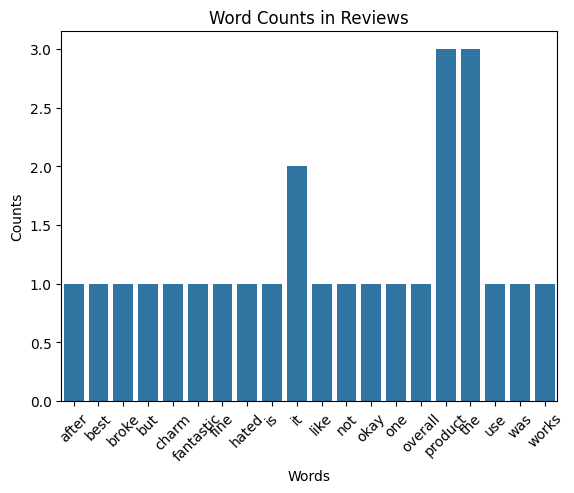

In [28]:
# Get word counts
word_counts = np.sum(X.toarray(), axis=0)
# Get words
words = vectorizer.get_feature_names_out()

sns.barplot(x=words, y=word_counts)
plt.title("Word Counts in Reviews")
plt.xlabel("Words")
plt.ylabel("Counts")
plt.xticks(rotation=45)
plt.show()

# Token Classification and Text Generation

## Token classification

Identifying named entities in news headlines

News organizations often tag named entities like people, locations, and organizations in headlines to improve search, indexing, and recommendations. Your job is to use a Hugging Face pipeline to automatically detect and group these entities in a news headline.

In [16]:
!pip install -U transformers accelerate sentencepiece

In [1]:
from transformers import pipeline
# Create the NER pipeline
ner_pipeline = pipeline(
    task="ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
headline = "Apple is planning to open a new office in San Francisco next year."

# Get named entities
entities = ner_pipeline(headline)

for entity in entities:
    print(f"{entity['entity_group']}: {entity['word']}")

ORG: Apple
LOC: San Francisco


In [3]:
from transformers import pipeline
# Create the PoS tagging pipeline
pos_pipeline = pipeline(
    task="token-classification",
    model="vblagoje/bert-english-uncased-finetuned-pos",
    aggregation_strategy="simple"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: vblagoje/bert-english-uncased-finetuned-pos
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

i: PRON
am: AUX
meeting: VERB
my: PRON
friends: NOUN
for: ADP
coffee: NOUN
this: DET
afternoon: NOUN
.: PUNCT


In [5]:

sentence = ''''''

# Get PoS tags
pos_tags = pos_pipeline(sentence)
for token in pos_tags:
    print(f"{token['word']}: {token['entity_group']}")

good: ADJ
—: PUNCT
that: SCONJ
clarification: NOUN
matters: VERB
.: PUNCT
you: PRON
’ re: AUX
* *: PUNCT
not: PART
“: ADJ
learning: VERB
ml: NOUN
”: PUNCT
anymore: ADV
* *.: PUNCT
you: PRON
’ re: AUX
* *: PUNCT
transitioning: VERB
from: ADP
classical: ADJ
ml: NOUN
→: SYM
deep: ADJ
learning practitioner: NOUN
* *.: PUNCT
so: ADV
this: PRON
will be: AUX
a: DET
*: PUNCT
*: SYM
dl: NOUN
-: PUNCT
focused: VERB
,: PUNCT
execution: NOUN
-: PUNCT
first: ADJ
30: NUM
-: PUNCT
day plan: NOUN
* *,: PUNCT
assuming: VERB
ml fundamentals: NOUN
are: AUX
done: VERB
.: PUNCT
below: ADV
is: AUX
what i: PRON
’ d: AUX
do: VERB
* *: PUNCT
if: SCONJ
my: PRON
job: NOUN
was: VERB
to: PART
save: VERB
you: PRON
time: NOUN
every: DET
single: ADJ
day: NOUN
* *. - - -: PUNCT
#: SYM
30: NUM
-: PUNCT
day: NOUN
deep: ADJ
learning execution plan: NOUN
(: PUNCT
no: DET
excuses: NOUN
) * *: PUNCT
principles: NOUN
(: PUNCT
important: ADJ
) : * * *: PUNCT
no: DET
“ watch: NOUN
-: PUNCT
only: ADV
” learning: NOUN
*: PUNCT
n

## Question answering


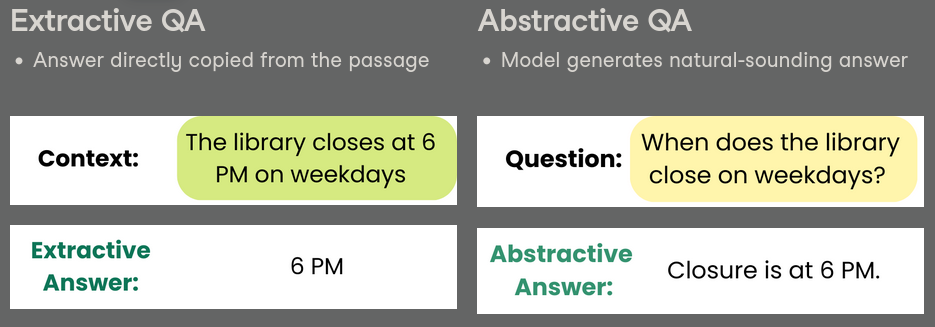

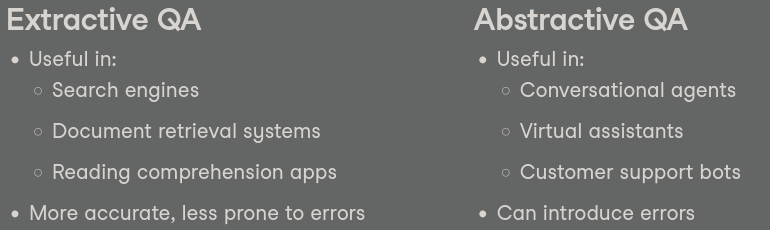

In [7]:
from transformers import pipeline

# Create the question-answering pipeline
qa_pipeline = pipeline(
    task="question-answering",
    model="distilbert/distilbert-base-cased-distilled-squad"
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

In [8]:
#Extractive QA
context = """This smartphone features a 6.5-inch OLED display, 128GB of storage, and a 48MP camera with night mode. It supports 5G connectivity and has a battery life of up to 24 hours."""

question = "What is the size of the smartphone's display?"

# Get the answer
result = qa_pipeline(question=question,context=context)
print(result)

{'score': 0.8668780326843262, 'start': 27, 'end': 35, 'answer': '6.5-inch'}


In [12]:
# Abstractive QA
from transformers import pipeline

# Create the abstractive question-answering pipeline
qa_pipeline = pipeline(
    task="text-generation",
    model="fangyuan/hotpotqa_abstractive"
)

pytorch_model.bin:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'ExaoneMoeForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalL

In [13]:
context = """This smartphone features a 6.5-inch OLED display, 128GB of storage, and a 48MP camera with night mode. It supports 5G connectivity and has a battery life of up to 24 hours."""

question = "What is the size of the smartphone's display?"

# Generate abstractive answer
result = qa_pipeline(f"question: {question} context: {context}")
print(result)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "question: What is the size of the smartphone's display? context: This smartphone features a 6.5-inch OLED display, 128GB of storage, and a 48MP camera with night mode. It supports 5G connectivity and has a battery life of up to 24 hours."}]


## Sequence generation tasks

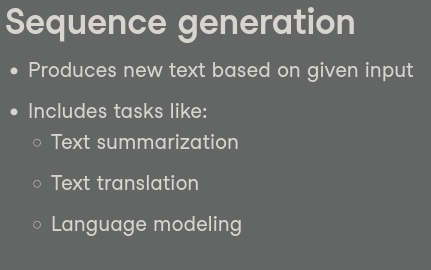

In [ ]:
from transformers import pipeline

# Create the summarization pipeline
summarizer = pipeline(task="summarization", model="cnicu/t5-small-booksum")

article = """NASA's Perseverance rover has successfully collected its first rock samples from Mars, marking a significant milestone in the mission. The samples will be stored for potential return to Earth in the future, providing valuable insight into the planet's geology and potential signs of past microbial life."""

# Generate the summary
summary = summarizer(article)

print(summary)

In [235]:


article = """NASA's Perseverance rover has successfully collected its first rock samples from Mars, marking a significant milestone in the mission. The samples will be stored for potential return to Earth in the future, providing valuable insight into the planet's geology and potential signs of past microbial life."""

# Generate the summary
summary = [{'summary_text': 'Perseverance rover has successfully collected its first rock samples from Mars, marking a significant milestone in the mission . the samples will be stored for potential return to Earth in the future .'}]
print(summary)

[{'summary_text': 'Perseverance rover has successfully collected its first rock samples from Mars, marking a significant milestone in the mission . the samples will be stored for potential return to Earth in the future .'}]


translation

In [ ]:
from transformers import pipeline

# Create the translation pipeline
translator = pipeline(task="translation", model="Helsinki-NLP/opus-mt-en-fr")

review = "The hotel was clean and the staff were very friendly."

In [246]:
# Translate the review
translation = [{'translation_text': "L'hôtel était propre et le personnel très sympathique."}] #translator(review)

print(translation)

[{'translation_text': "L'hôtel était propre et le personnel très sympathique."}]


In [247]:
from transformers import pipeline

# Create the pipeline
autocomplete = pipeline(task="text-generation", model="distilgpt2")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [249]:
prompt = "Best books to read for"

# Generate search query completions
suggestions = autocomplete(prompt,max_length=8,num_return_sequences=3)

for suggestion in suggestions:
    print(suggestion['generated_text'])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=8) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Best books to read for the first time: The American Novel, Harper’s, and The Last of Us.













































































































































































































































Best books to read for you.






























































































































































































































































Best books to read for the first time.




And, I‪m waiting for some more!

I‪m going to miss you guys.
